# Dataset

We first load the dataset using the kagglehub package, that will automatically download the fer2013 and cache it.
Then, we extract and import it by separating the training images from the testing images.

In [1]:
import kagglehub
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

######## Import dataset ########
path = kagglehub.dataset_download("msambare/fer2013")

train_path = f"{path}/train"
test_path = f"{path}/test"

def load_images(folder_path):
    images = []
    labels = []
    
    classes = sorted([
        folder for folder in os.listdir(folder_path)
        if os.path.isdir(os.path.join(folder_path, folder))
    ])
    
    class_to_label = {class_name: i for i, class_name in enumerate(classes)}
    
    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)
        label = class_to_label[class_name]
        
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            
            try:
                image = Image.open(file_path).convert("L")
                image = np.array(image, dtype=np.float32) / 255.0
                
                images.append(image)
                labels.append(label)
            except Exception:
                pass
    
    return np.array(images), np.array(labels), classes

# Load
im_train, y_train, classes = load_images(train_path)
im_test, y_test, _ = load_images(test_path)


/home/nathan/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Next we visualize the first image and its associated label to check the dataset.

Classes:  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of training images:  28709 
Number of testing images:  7178
======== First image of the training dataset ========
Image is of shape (48, 48) , with label angry which corresponds to index 0


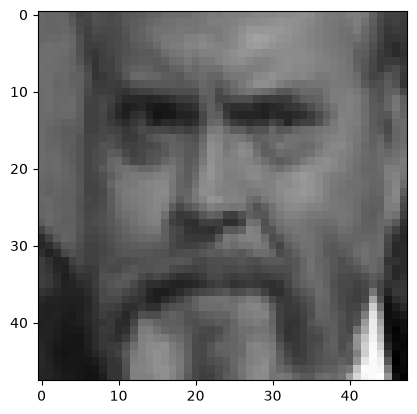

In [2]:
# Check dataset
print("Classes: ", classes)

print("Number of training images: ", len(im_train), "\nNumber of testing images: ", len(im_test))


print("======== First image of the training dataset ========")
image = im_train[0]
label = y_train[0]
plt.imshow(image, cmap='gray')

print("Image is of shape", image.shape, ", with label", classes[label], "which corresponds to index", label)

# LBP extraction

Then we want to extract the useful feature of each image, by using local binary pattern. We first calculate the image of the LBP, and then its histogram which will contain all the information useful for our KNN.

In [3]:
######## LBP ########
from skimage.feature import local_binary_pattern

LBPs_train = []
LBPs_test = []
X_train = []
X_test = []
for im in im_train:
    lbp = local_binary_pattern(im, P=8, R=1, method='default')
    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256), density=True)
    LBPs_train.append(lbp)
    X_train.append(hist)
for im in im_test:
    lbp = local_binary_pattern(im, P=8, R=1, method='default')
    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256), density=True)
    LBPs_test.append(lbp)
    X_test.append(hist)


/home/nathan/miniconda3/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


We can also visualize the lbp as well as the histogram to see which features are being extracted from the input image.

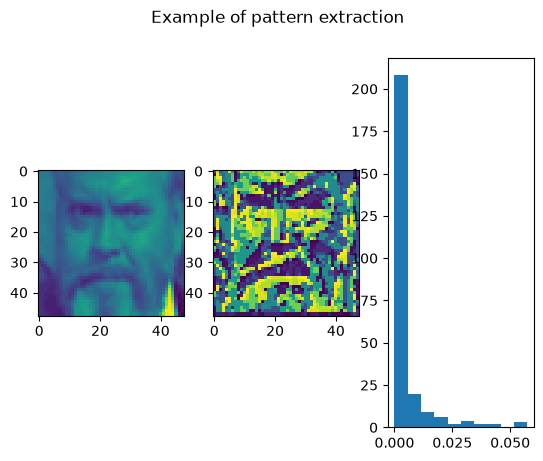

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.suptitle('Example of pattern extraction')
ax1.imshow(im_train[0])
ax2.imshow(LBPs_train[0])
ax3.hist(X_train[0])
plt.show()

# KNN training

We can now start fitting our KNN model, first by choosing the n parameter, and then fitting it with the training data.

In [5]:
######## KNN ########
from sklearn.neighbors import KNeighborsClassifier

# Fit the model
neigh = KNeighborsClassifier(n_neighbors=5)

neigh.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# Validation

Then, we use the testing data to verify the accuracy of our KNN model. We also plot the confusion matrix to detect whether the model predicts correctly.

===== KNN Results =====
Accuracy : 0.3210
Precision: 0.3304

===== Precision per Emotion =====
              precision    recall  f1-score   support

       angry     0.2425    0.3445    0.2846       958
     disgust     0.3689    0.3423    0.3551       111
        fear     0.3098    0.3086    0.3092      1024
       happy     0.3610    0.4662    0.4069      1774
     neutral     0.2640    0.2174    0.2384      1233
         sad     0.3136    0.1868    0.2342      1247
    surprise     0.4527    0.3514    0.3957       831

    accuracy                         0.3210      7178
   macro avg     0.3304    0.3167    0.3177      7178
weighted avg     0.3237    0.3210    0.3156      7178



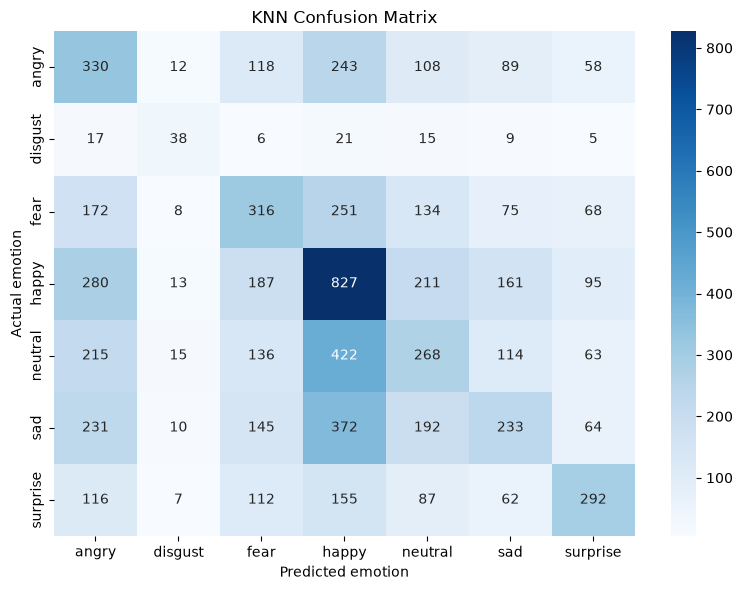

In [6]:
######## Test the model ########
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns

# Predict test labels
y_pred = neigh.predict(X_test)

# Metrics
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)

print("===== KNN Results =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")

# Precision for each emotion

print("\n===== Precision per Emotion =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=classes,
    digits=4,
    labels=np.arange(len(classes)),
    zero_division=0
))


# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted emotion")
plt.ylabel("Actual emotion")
plt.title("KNN Confusion Matrix")

plt.tight_layout()
plt.show()

As we can see, the accuracy is really low and the model makes a lot of mistakes.

# Inference

Finally, we can play a bit with the model and the camera to live detect the emotion of a person. The pipeline is as following: first, we detect a face with opencv, and then crop it to 48\*48 pixel and convert it to grayscale ; then we can pass its histogram to the KNN model and get the prediction, that we show in a corner of the capture window.

In [7]:
######## Camera inference ########

import cv2
import time
import numpy as np
from skimage.feature import local_binary_pattern

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    print("Error: Could not load face detector.")
    exit()


cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open camera.")
    exit()

print("Camera started.")
print("Press 'q' to quit.")

while True:
    # Capture frame
    ret, frame = cap.read()

    if not ret:
        print("Error: Could not read frame.")
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))

    if len(faces) > 0:

        # Select the largest face
        x, y, w, h = max(faces, key=lambda face: face[2] * face[3])

        # Draw face rectangle
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Crop ONLY the detected face
        face = gray[y:y+h, x:x+w]

        # Resize face to FER-2013 size: 48 x 48
        face_48 = cv2.resize(face, (48, 48), interpolation=cv2.INTER_AREA)

        # Normalize
        image = face_48.astype(np.float32) / 255.0

        # ── Timed section ──────────────────────────────────────
        t_start = time.perf_counter()

        # Extract LBP
        lbp = local_binary_pattern(image, P=8, R=1, method="default")

        # Create LBP histogram
        hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256), density=True)

        # Reshape for KNN
        hist = hist.reshape(1, -1)

        t_lbp = time.perf_counter()

        # Predict emotion
        prediction = neigh.predict(hist)[0]

        t_end = time.perf_counter()
        # ───────────────────────────────────────────────────────

        ms_lbp    = (t_lbp - t_start) * 1000
        ms_knn    = (t_end  - t_lbp)  * 1000
        ms_total  = (t_end  - t_start) * 1000

        emotion = classes[prediction]

        # Display emotion
        cv2.putText(frame, f"Emotion: {emotion}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Display timings
        cv2.putText(frame, f"LBP+hist : {ms_lbp:.1f} ms", (20, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 0), 2)
        cv2.putText(frame, f"KNN pred : {ms_knn:.1f} ms", (20, 110),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 0), 2)
        cv2.putText(frame, f"Total    : {ms_total:.1f} ms", (20, 140),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # Show the actual 48x48 input
        face_display = cv2.resize(face_48, (240, 240), interpolation=cv2.INTER_NEAREST)
        cv2.imshow("48x48 Face Input", face_display)

    else:
        cv2.putText(frame, "No face detected", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # Show camera
    cv2.imshow("Emotion Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Camera started.
Press 'q' to quit.


/home/nathan/miniconda3/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/home/nathan/miniconda3/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/home/nathan/miniconda3/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
